# BTCUSDC Order-Flow Study: Return, Covariance, And Correlation Scaling

This notebook studies how a raw order-flow signal lines up with later price moves on the `BTCUSDC / 20260223` trade stream.

We use the same generalized imbalance signal as notebook 02, but we now separate two horizons:

- `T_signal`: the number of past trades used to build the imbalance signal,
- `H_return`: the number of future trades used to measure the price move.

In this notebook we keep a paper-style same-horizon comparison by setting `T_signal = H_return = common_horizon`.

The two main questions are:

- does the signal move with price in raw units,
- does that relationship remain strong after normalization.


## Plain-Language Guide

This notebook is written for readers who may not have market microstructure background.

- `BTCUSDC` means Bitcoin traded against USD Coin.
- `midprice` means the average of the best bid and best ask in the order book.
- `order-flow signal` means a signed running sum of trades, where buyer-initiated trades count positive and seller-initiated trades count negative.
- `future return` means the log price change from now to a later trade index. For small moves this is close to a percentage return.
- `T_signal` means the number of past trades used to build the signal.
- `H_return` means the number of future trades used to measure the later price move.
- `common_horizon` means we set `T_signal` and `H_return` to the same trade count for this notebook.
- `a` controls how strongly large trades are weighted. `a = 0` uses only trade direction, while larger `a` values give more weight to large trade size.
- `UTC` means Coordinated Universal Time, the timezone used in the summary table below.


## What Covariance Means

`E[Delta_H * I_{T_signal}^a]` measures raw co-movement between future price changes and the imbalance signal.

Interpretation:

- positive values mean buy-heavy signals tend to line up with upward price moves,
- negative values mean the opposite,
- values near zero mean weak linear coupling.

This is useful because it keeps the original scale of the two variables, so it shows how much joint movement we see before any normalization.

Caveat:

- if one variable is rescaled, covariance changes,
- so covariance is informative, but it is not directly comparable across all horizon choices without context.


## What Correlation Means

Correlation is the normalized version of the same coupling:

`correlation(Delta_H, I_{T_signal}^a) = covariance(Delta_H, I_{T_signal}^a) / (standard deviation of Delta_H * standard deviation of I_{T_signal}^a)`

Interpretation:

- `+1` means perfect positive linear co-movement,
- `0` means no linear relationship,
- `-1` means perfect negative linear co-movement.

Why we need it:

- it removes units,
- it makes different horizon choices and `a` values comparable,
- it shows whether imbalance remains informative after normalization, not just large in absolute magnitude.

So the notebook uses both:

- covariance for raw coupling,
- correlation for normalized coupling.


## Why Both Matter Together

Covariance answers: "How much joint movement is there in native units?"

Correlation answers: "Is the relationship still strong after we remove scale?"

That distinction matters because a large covariance can come from a large signal scale, while correlation tells us whether the price and signal link is genuinely strong across horizons and weighting choices.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


In [2]:
def find_backtester_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "stats").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the exchange-data-backtester project root")


def resolve_day_dir(project_root: Path, *, symbol: str, day: str) -> Path:
    candidates = [
        project_root.parent / "exchange-data-recorder" / "data" / symbol / day,
        project_root.parent / "exchange-data-recorder" / "data" / "binance" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / "binance" / symbol / day,
        project_root / "data" / symbol / day,
        project_root / "data" / "binance" / symbol / day,
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / "schema.json").is_file():
            return candidate
    raise FileNotFoundError(f"Could not locate a recorder day folder for {symbol}/{day}")


PROJECT_ROOT = find_backtester_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT


PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-backtester')

## Planned Computations

The implementation compares the future return `Delta_H` and the imbalance signal `I_{T_signal}^a` on a grid of common trade horizons and size weights `a`.

Main outputs:

- a scatter plot of raw signal versus future return for one representative case,
- `E[Delta_H * I_{T_signal}^a]` versus the common horizon and `a`,
- correlation line plots,
- heatmaps over `(common_horizon, a)`.

A later decay notebook will let `T_signal` and `H_return` differ. This notebook keeps them equal on purpose.


## Horizon Convention

There are two horizons in principle:

- `T_signal`: the number of past trades used in the imbalance signal,
- `H_return`: the number of future trades used in the return.

In this notebook we set them equal and call that shared value `common_horizon`.

That means:

- `I_{T_signal}^a` uses the last `common_horizon` trades,
- `Delta_H` uses the next `common_horizon` trades.

This keeps the signal and return on the same raw-trade clock while making the two roles explicit.


In [3]:
from stats.io import load_day
from stats.notebook import replay_summary
from stats.tables import get_or_build_top_of_book_table, get_or_build_trades_table


symbol = "BTCUSDC"
day = "20260223"
day_dir = resolve_day_dir(PROJECT_ROOT, symbol=symbol, day=day)

dataset = load_day(day_dir)
trades = get_or_build_trades_table(dataset)
top = get_or_build_top_of_book_table(dataset, on_gap="skip-segment")
replay_info = replay_summary(dataset, replay_on_gap="skip-segment")

day_dir


PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-recorder/data/binance/BTCUSDC/20260223')

In [4]:
def rolling_window_sum(x: np.ndarray, T: int) -> np.ndarray:
    if T <= 0:
        raise ValueError("T must be positive")
    x = np.asarray(x, dtype=float)
    out = np.full(len(x), np.nan, dtype=float)
    if len(x) < T:
        return out
    csum = np.cumsum(np.insert(x, 0, 0.0))
    out[T - 1 :] = csum[T:] - csum[:-T]
    return out


def build_imbalance_series(sign: np.ndarray, qty: np.ndarray, T: int, a: float) -> np.ndarray:
    weighted = sign * np.power(qty, a)
    return rolling_window_sum(weighted, T)


def make_trade_aligned_frame(trades_df: pd.DataFrame, top_df: pd.DataFrame) -> pd.DataFrame:
    trade_frame = trades_df[["ts", "qty", "aggr_sign", "price"]].copy()
    trade_frame = trade_frame[np.isfinite(trade_frame["qty"]) & np.isfinite(trade_frame["aggr_sign"])].copy()
    trade_frame = trade_frame.sort_values("ts").reset_index(drop=True)
    book_mid = top_df[["ts", "mid"]].dropna().sort_values("ts").rename(columns={"mid": "mid_at_book"})
    aligned = pd.merge_asof(trade_frame, book_mid, on="ts", direction="backward")
    aligned = aligned.dropna(subset=["mid_at_book"]).reset_index(drop=True)
    aligned["trade_idx"] = np.arange(len(aligned))
    aligned["log_mid"] = np.log(aligned["mid_at_book"])
    return aligned


trade_frame = make_trade_aligned_frame(trades, top)
trade_frame.head()


,ts,qty,aggr_sign,price,mid_at_book,trade_idx,log_mid
0,2026-02-23 01:00:04.958000+00:00,0.00009,1.0,66704.44,66704.435,0,11.108027
1,2026-02-23 01:00:04.958000+00:00,0.00017,1.0,66704.44,66704.435,1,11.108027
2,2026-02-23 01:00:05.037000+00:00,0.00989,1.0,66704.44,66704.435,2,11.108027
3,2026-02-23 01:00:05.087000+00:00,0.00123,-1.0,66704.43,66704.435,3,11.108027
4,2026-02-23 01:00:05.087000+00:00,0.00008,-1.0,66702.01,66704.435,4,11.108027


In [5]:
T_list = np.array([5, 10, 20, 50, 100, 200, 500], dtype=int)
a_list = np.array([0.0, 0.1, 0.2, 0.3, 0.5, 1.0, 1.5, 2.0], dtype=float)

sign = trade_frame["aggr_sign"].to_numpy(dtype=float)
qty = trade_frame["qty"].to_numpy(dtype=float)
mid = trade_frame["mid_at_book"].to_numpy(dtype=float)

summary = pd.Series({
    "rows_after_alignment": len(trade_frame),
    "trade_start_utc": trade_frame["ts"].min(),
    "trade_end_utc": trade_frame["ts"].max(),
    "mid_start": trade_frame["mid_at_book"].min(),
    "mid_end": trade_frame["mid_at_book"].max(),
    "segments_total": replay_info["segments_total"],
    "segments_kept": replay_info["segments_kept"],
})

display(summary.to_frame("value"))
display(trade_frame[["ts", "qty", "aggr_sign", "mid_at_book", "trade_idx"]].head())


,value
rows_after_alignment,868008
trade_start_utc,2026-02-23 01:00:04.958000+00:00
trade_end_utc,2026-02-23 23:15:00.320000+00:00
mid_start,63874.005
mid_end,66704.435
segments_total,1
segments_kept,1


,ts,qty,aggr_sign,mid_at_book,trade_idx
0,2026-02-23 01:00:04.958000+00:00,0.00009,1.0,66704.435,0
1,2026-02-23 01:00:04.958000+00:00,0.00017,1.0,66704.435,1
2,2026-02-23 01:00:05.037000+00:00,0.00989,1.0,66704.435,2
3,2026-02-23 01:00:05.087000+00:00,0.00123,-1.0,66704.435,3
4,2026-02-23 01:00:05.087000+00:00,0.00008,-1.0,66704.435,4


## Trade-Aligned Return Construction

For each trade index `t`, we define the forward log return over horizon `H_return` as:

`Delta_H(t) = log(mid_{t+H_return}) - log(mid_t)`

The imbalance window stays backward-looking: `I_{T_signal}^a(t)` uses the last `T_signal` trades up to `t`.
In this notebook we set `T_signal = H_return = common_horizon`, which keeps the coupling test free of look-ahead and makes the notation less ambiguous.


In [15]:
def build_cov_corr_frame(trade_frame: pd.DataFrame, signal_T: int, return_H: int, a: float) -> pd.DataFrame:
    sign = trade_frame["aggr_sign"].to_numpy(dtype=float)
    qty = trade_frame["qty"].to_numpy(dtype=float)
    log_mid = trade_frame["log_mid"].to_numpy(dtype=float)

    imbalance = build_imbalance_series(sign, qty, T=signal_T, a=a)
    delta = np.full(len(log_mid), np.nan, dtype=float)
    if len(log_mid) > return_H:
        delta[:-return_H] = log_mid[return_H:] - log_mid[:-return_H]

    out = pd.DataFrame({"I": imbalance, "delta": delta}).dropna().copy()
    return out


def summarize_cov_corr(frame: pd.DataFrame) -> pd.Series:
    x = frame["I"].to_numpy(dtype=float)
    y = frame["delta"].to_numpy(dtype=float)
    if len(x) == 0:
        return pd.Series({"cov": np.nan, "corr": np.nan, "n": 0})
    cov = float(np.mean((x - x.mean()) * (y - y.mean())))
    corr = float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else np.nan
    return pd.Series({"cov": cov, "corr": corr, "n": len(x)})


demo_signal_T = 10
demo_return_H = 20
demo_a = 0.2
demo_frame = build_cov_corr_frame(trade_frame, signal_T=demo_signal_T, return_H=demo_return_H, a=demo_a)
display(demo_frame.head())
display(summarize_cov_corr(demo_frame).to_frame("value"))


,I,delta
9,-0.515498,-0.000145
10,-0.822254,-0.000145
11,-0.621544,-0.000145
12,-1.366172,-0.000096
13,-1.259549,-0.000096


,value
cov,0.000117
corr,0.446194
n,867979.000000


## Raw Signal Versus Future Return

The next plot uses one concrete choice, `T_signal = 10` trades, `H_return = 10` trades, and `a = 0.3`, so the relationship is easier to see before we move to full grids.

Each point is one anchor trade:

- the horizontal axis is the raw imbalance signal built from the last `10` trades,
- the vertical axis is the future log return over the next `10` trades.

The scatter plot uses a random sample of points so the cloud stays visible. The right-hand panel groups the signal into equal-count buckets and shows the average future return in each bucket.


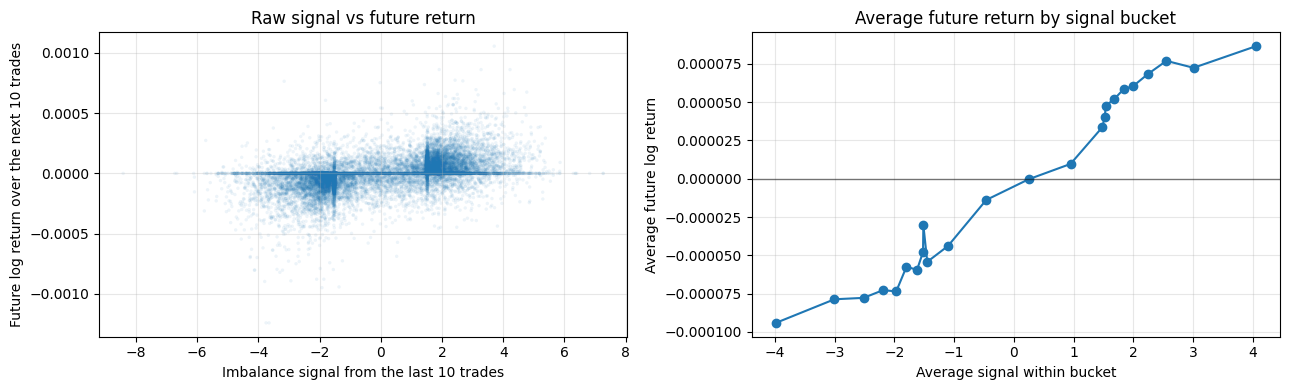

In [16]:
scatter_frame = build_cov_corr_frame(trade_frame, signal_T=demo_signal_T, return_H=demo_return_H, a=demo_a)

plot_sample_n = min(20000, len(scatter_frame))
plot_sample = scatter_frame.sample(plot_sample_n, random_state=7).sort_values("I")

bucket_view = (
    plot_sample.assign(signal_bucket=pd.qcut(plot_sample["I"], q=25, duplicates="drop"))
    .groupby("signal_bucket", observed=False)
    .agg(signal_mean=("I", "mean"), future_return_mean=("delta", "mean"), point_count=("delta", "size"))
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(plot_sample["I"], plot_sample["delta"], s=6, alpha=0.08, edgecolors="none")
axes[0].set_title("Raw signal vs future return")
axes[0].set_xlabel("Imbalance signal from the last 10 trades")
axes[0].set_ylabel("Future log return over the next 10 trades")
axes[0].grid(True, alpha=0.3)

axes[1].plot(bucket_view["signal_mean"], bucket_view["future_return_mean"], marker="o")
axes[1].axhline(0.0, color="black", linewidth=1, alpha=0.5)
axes[1].set_title("Average future return by signal bucket")
axes[1].set_xlabel("Average signal within bucket")
axes[1].set_ylabel("Average future log return")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
common_horizon_list = T_list.copy()
grid_rows = []

for a in a_list:
    for common_horizon in common_horizon_list:
        frame = build_cov_corr_frame(
            trade_frame,
            signal_T=int(common_horizon),
            return_H=int(common_horizon),
            a=float(a),
        )
        summary_row = summarize_cov_corr(frame)
        grid_rows.append({
            "a": float(a),
            "common_horizon": int(common_horizon),
            "signal_T": int(common_horizon),
            "return_H": int(common_horizon),
            "cov": float(summary_row["cov"]),
            "corr": float(summary_row["corr"]),
            "n": int(summary_row["n"]),
        })

grid_df = pd.DataFrame(grid_rows)
display(grid_df.head())


,a,common_horizon,signal_T,return_H,cov,corr,n
0,0.0,5,5,5,0.000091,0.336728,867999
1,0.0,10,10,10,0.000297,0.394256,867989
2,0.0,20,20,20,0.000812,0.389714,867969
3,0.0,50,50,50,0.002163,0.278185,867909
4,0.0,100,100,100,0.003551,0.175621,867809


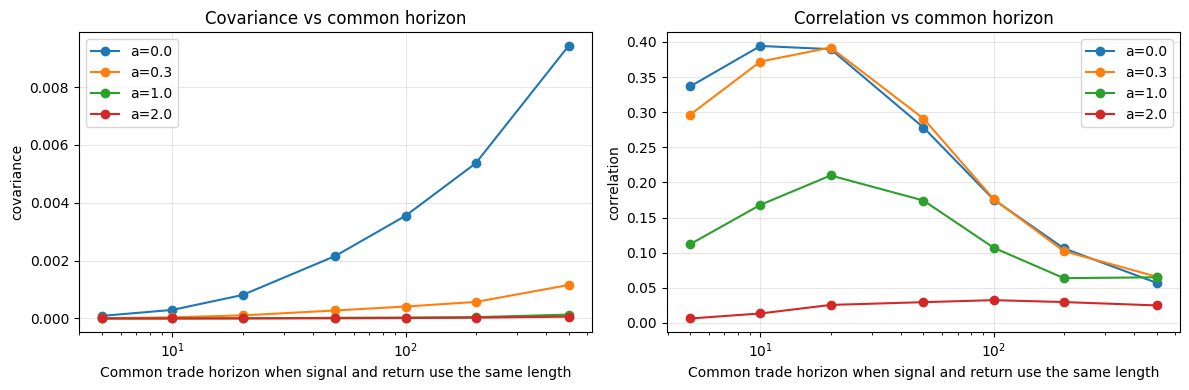

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for a in [0.0, 0.3, 1.0, 2.0]:
    tmp = grid_df[grid_df["a"] == a].sort_values("common_horizon")
    axes[0].plot(tmp["common_horizon"], tmp["cov"], marker="o", label=f"a={a}")
    axes[1].plot(tmp["common_horizon"], tmp["corr"], marker="o", label=f"a={a}")

axes[0].set_xscale("log")
axes[0].set_title("Covariance vs common horizon")
axes[0].set_xlabel("Common trade horizon when signal and return use the same length")
axes[0].set_ylabel("covariance")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xscale("log")
axes[1].set_title("Correlation vs common horizon")
axes[1].set_xlabel("Common trade horizon when signal and return use the same length")
axes[1].set_ylabel("correlation")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


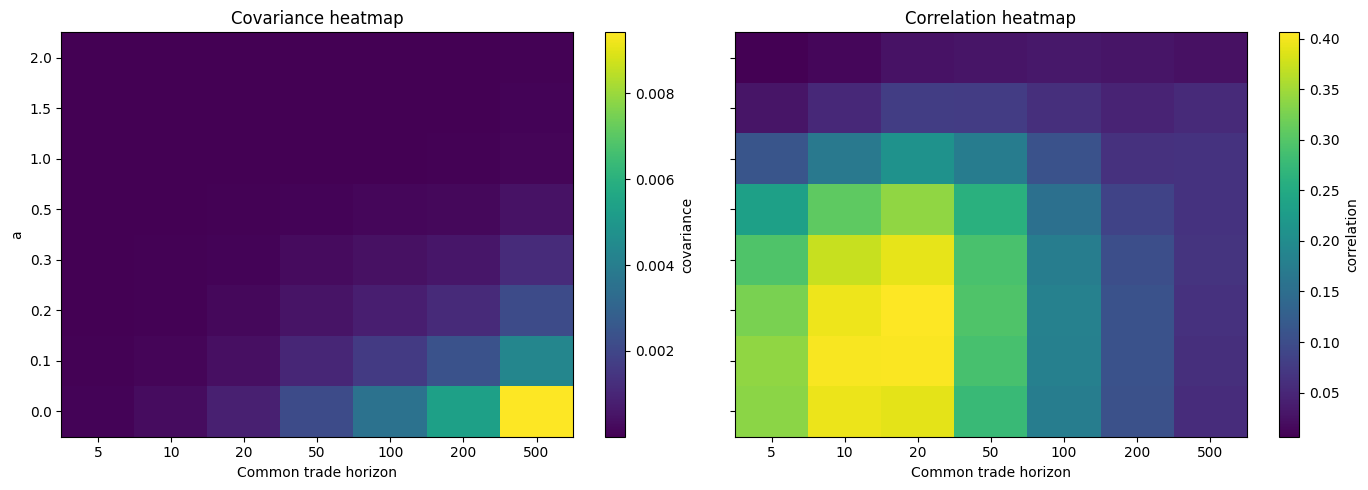

In [10]:
cov_pivot = grid_df.pivot(index="a", columns="common_horizon", values="cov")
corr_pivot = grid_df.pivot(index="a", columns="common_horizon", values="corr")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

im0 = axes[0].imshow(cov_pivot.values, aspect="auto", origin="lower")
axes[0].set_title("Covariance heatmap")
axes[0].set_xticks(range(len(cov_pivot.columns)))
axes[0].set_xticklabels(cov_pivot.columns)
axes[0].set_yticks(range(len(cov_pivot.index)))
axes[0].set_yticklabels(cov_pivot.index)
axes[0].set_xlabel("Common trade horizon")
axes[0].set_ylabel("a")
fig.colorbar(im0, ax=axes[0], label="covariance")

im1 = axes[1].imshow(corr_pivot.values, aspect="auto", origin="lower")
axes[1].set_title("Correlation heatmap")
axes[1].set_xticks(range(len(corr_pivot.columns)))
axes[1].set_xticklabels(corr_pivot.columns)
axes[1].set_yticks(range(len(corr_pivot.index)))
axes[1].set_yticklabels(corr_pivot.index)
axes[1].set_xlabel("Common trade horizon")
fig.colorbar(im1, ax=axes[1], label="correlation")

plt.tight_layout()
plt.show()
